# Grafos con la red del club de karate de Zachary

Este notebook está pensado para que el alumnado aprenda conceptos fundamentales de teoría de grafos usando un caso clásico:
la **red del club de karate de Zachary**.

## Objetivos
En este notebook vamos a:

1. Cargar y explorar la red.
2. Visualizarla de varias formas.
3. Estudiar la **distribución de grados**.
4. Calcular medidas de **centralidad**.
5. Analizar distancias y caminos cortos.
6. Estudiar el clustering y otras propiedades globales.
7. Detectar comunidades.
8. Simular qué pasa si eliminamos nodos importantes.
9. Proponer ejercicios para practicar.

## Contexto
Wayne W. Zachary estudió las relaciones sociales entre los miembros de un club de karate. Durante el estudio surgió un conflicto
que dividió el club en dos grupos. Esta red se ha convertido en un ejemplo clásico en análisis de redes.

> En `networkx`, esta red viene incluida como dataset de ejemplo.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import numpy as np

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True


## 1. Cargar la red y explorarla

Primero cargamos el grafo y miramos sus propiedades básicas.


In [2]:
G = nx.karate_club_graph()

print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de aristas: {G.number_of_edges()}")
print(f"¿Es conexo?: {nx.is_connected(G)}")
print(f"Densidad: {nx.density(G):.4f}")
print(f"Diámetro: {nx.diameter(G)}")
print(f"Radio: {nx.radius(G)}")


Número de nodos: 34
Número de aristas: 78
¿Es conexo?: True
Densidad: 0.1390
Diámetro: 5
Radio: 3


## 2. Visualización básica de la red

Una primera visualización ayuda mucho a entender la estructura del grafo.


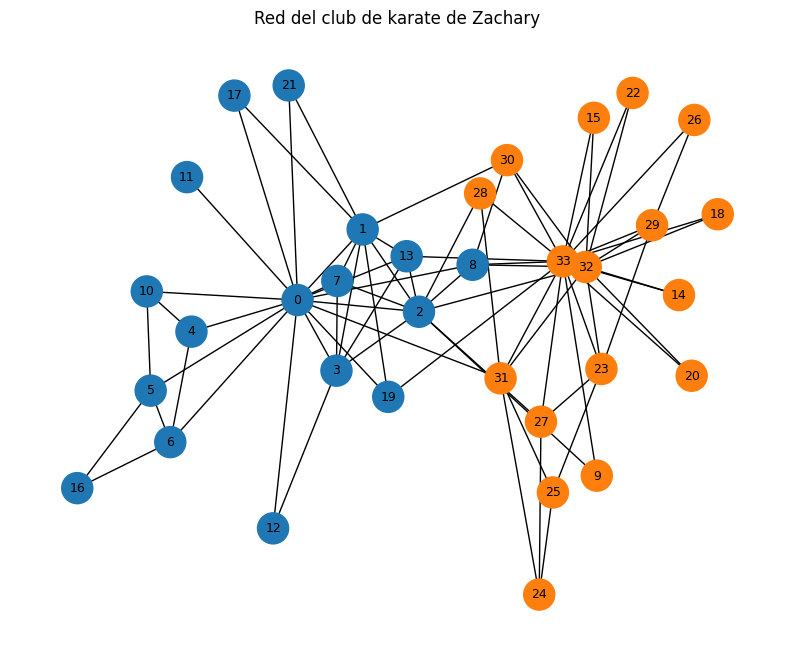

In [4]:
pos = nx.spring_layout(G, seed=7)

club_colors = [
    "tab:blue" if G.nodes[n]["club"] == "Mr. Hi" else "tab:orange"
    for n in G.nodes()
]

plt.figure(figsize=(10, 8))
nx.draw_networkx(
    G,
    pos=pos,
    node_color=club_colors,
    with_labels=True,
    node_size=500,
    font_size=9
)
plt.title("Red del club de karate de Zachary")
plt.axis("off")
plt.show()


## 3. Grado de los nodos y distribución de grados

El **grado** de un nodo es el número de vecinos que tiene.


In [5]:
degrees = dict(G.degree())

degree_df = (
    pd.DataFrame({
        "node": list(degrees.keys()),
        "degree": list(degrees.values()),
        "club": [G.nodes[n]["club"] for n in degrees.keys()]
    })
    .sort_values("degree", ascending=False)
    .reset_index(drop=True)
)

degree_df.head(10)


,node,degree,club
0,33,17,Officer
1,0,16,Mr. Hi
2,32,12,Officer
3,2,10,Mr. Hi
4,1,9,Mr. Hi
5,3,6,Mr. Hi
6,31,6,Officer
7,23,5,Officer
8,8,5,Mr. Hi
9,13,5,Mr. Hi


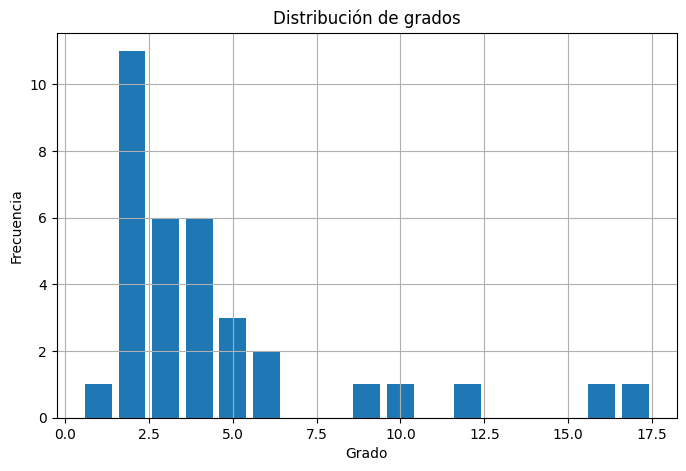

In [27]:
degree_counts = Counter(degrees.values())

# Ordenar por frecuencia (de mayor a menor)
sorted_counts = sorted(degree_counts.items(), key=lambda x: x[1], reverse=True)
deg, freq = zip(*sorted_counts)

plt.figure(figsize=(8, 5))
plt.bar(deg, freq)
plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.title("Distribución de grados")
plt.show()

## 4. Centralidad de nodos

Las medidas de centralidad ayudan a detectar nodos influyentes o estructuralmente importantes.

Vamos a calcular:
- **Centralidad de grado**
- **Centralidad de cercanía**
- **Centralidad de intermediación (betweenness)**
- **Centralidad de vector propio (eigenvector)**


In [8]:
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": pd.Series(degree_centrality),
    "closeness": pd.Series(closeness_centrality),
    "betweenness": pd.Series(betweenness_centrality),
    "eigenvector": pd.Series(eigenvector_centrality),
    "club": [G.nodes[n]["club"] for n in G.nodes()]
})

centrality_df.sort_values("betweenness", ascending=False).head(10)


,node,degree,closeness,betweenness,eigenvector,club
0,0,0.484848,0.568966,0.437635,0.355483,Mr. Hi
33,33,0.515152,0.550000,0.304075,0.373371,Officer
32,32,0.363636,0.515625,0.145247,0.308651,Officer
2,2,0.303030,0.559322,0.143657,0.317189,Mr. Hi
31,31,0.181818,0.540984,0.138276,0.191036,Officer
8,8,0.151515,0.515625,0.055927,0.227405,Mr. Hi
1,1,0.272727,0.485294,0.053937,0.265954,Mr. Hi
13,13,0.151515,0.515625,0.045863,0.226470,Mr. Hi
19,19,0.090909,0.500000,0.032475,0.147911,Mr. Hi
5,5,0.121212,0.383721,0.029987,0.079481,Mr. Hi


In [9]:
centrality_df.sort_values("eigenvector", ascending=False).head(10)


,node,degree,closeness,betweenness,eigenvector,club
33,33,0.515152,0.550000,0.304075,0.373371,Officer
0,0,0.484848,0.568966,0.437635,0.355483,Mr. Hi
2,2,0.303030,0.559322,0.143657,0.317189,Mr. Hi
32,32,0.363636,0.515625,0.145247,0.308651,Officer
1,1,0.272727,0.485294,0.053937,0.265954,Mr. Hi
8,8,0.151515,0.515625,0.055927,0.227405,Mr. Hi
13,13,0.151515,0.515625,0.045863,0.226470,Mr. Hi
3,3,0.181818,0.464789,0.011909,0.211174,Mr. Hi
31,31,0.181818,0.540984,0.138276,0.191036,Officer
30,30,0.121212,0.458333,0.014412,0.174760,Officer


### Interpretación orientativa

- **Degree centrality**: quién está conectado con más gente.
- **Closeness centrality**: quién está, en promedio, más cerca del resto.
- **Betweenness centrality**: quién actúa más como puente entre zonas de la red.
- **Eigenvector centrality**: quién está conectado con nodos que también son importantes.


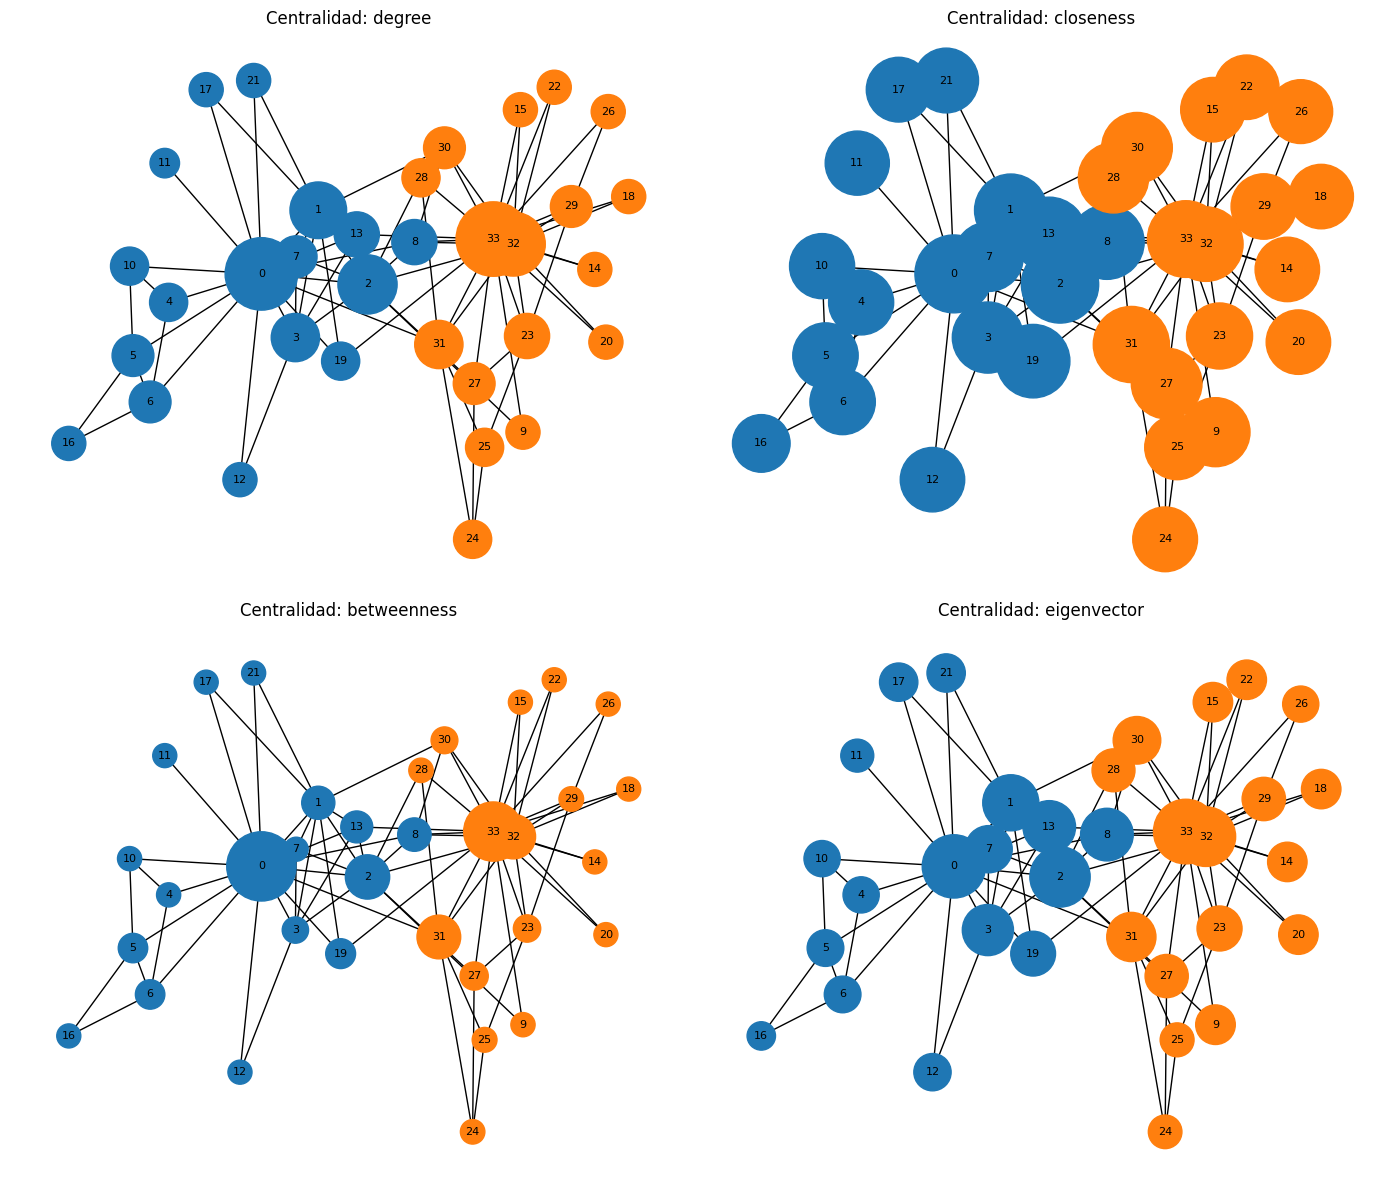

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
metrics = [
    ("degree", degree_centrality),
    ("closeness", closeness_centrality),
    ("betweenness", betweenness_centrality),
    ("eigenvector", eigenvector_centrality),
]

for ax, (title, metric) in zip(axes.flat, metrics):
    sizes = [300 + 5000 * metric[n] for n in G.nodes()]
    nx.draw_networkx(
        G,
        pos=pos,
        ax=ax,
        node_size=sizes,
        node_color=club_colors,
        with_labels=True,
        font_size=8
    )
    ax.set_title(f"Centralidad: {title}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Distancias y caminos cortos

Ahora analizamos cómo de lejos están los nodos entre sí.


In [11]:
path_lengths = dict(nx.all_pairs_shortest_path_length(G))
distances = []

for u in G.nodes():
    for v in G.nodes():
        if u < v:
            distances.append(path_lengths[u][v])

print(f"Longitud media del camino más corto: {nx.average_shortest_path_length(G):.4f}")
print(f"Diámetro: {nx.diameter(G)}")
print(f"Excentricidad de algunos nodos: {dict(list(nx.eccentricity(G).items())[:10])}")


Longitud media del camino más corto: 2.4082
Diámetro: 5
Excentricidad de algunos nodos: {0: 3, 1: 3, 2: 3, 3: 3, 4: 4, 5: 4, 6: 4, 7: 4, 8: 3, 9: 4}


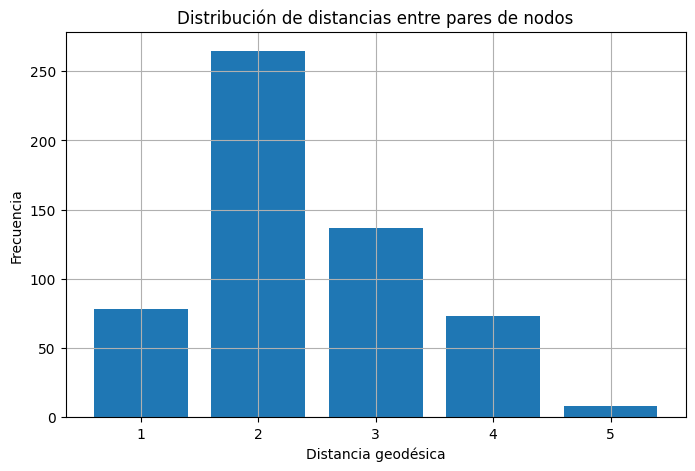

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(distances, bins=range(min(distances), max(distances) + 2), align="left", rwidth=0.8)
plt.xlabel("Distancia geodésica")
plt.ylabel("Frecuencia")
plt.title("Distribución de distancias entre pares de nodos")
plt.show()
